<a href="https://colab.research.google.com/github/arifisahakk/-Arif-Buuku/blob/main/CPC251_Project_Part2_Seismic(test).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CPC251 Project Part 2 - Seismic Bumps Prediction

This notebook builds two predictive models for the Seismic Bumps dataset. One model is a Keras Neural Network, and the second model is a Random Forest comparison model. The two models are intentionally different: the Neural Network learns a compact non-linear decision function, while Random Forest combines many decision trees to handle tabular feature interactions.

## Group Information

Group No: [Fill in assigned group number]

- Member 1: [Name] ([Matric No.])
- Member 2: [Name] ([Matric No.])
- Member 3: [Name] ([Matric No.])
- Member 4: [Name] ([Matric No.])

## Project Objective

Part 2 extends the modelling work by using a Neural Network and comparing it with a second predictive model. The target is still the same binary outcome: whether a high-energy seismic bump happens in the next mining shift. The positive class is rare, so the model has to learn from an imbalanced dataset where most examples are non-hazardous.

The Neural Network is included because it can learn non-linear relationships between the encoded seismic measurements. Random Forest is included as a strong tabular-data comparison model because it can capture feature interactions through an ensemble of decision trees. Comparing these two models helps answer whether a neural approach or a tree-ensemble approach is more suitable for the available seismic features.

In this notebook, the final model choice is discussed through both safety and operational perspectives. A safety-focused model should reduce missed hazardous shifts, while an operations-focused model should avoid too many false alarms. The metric table and confusion matrices are interpreted with both perspectives in mind.

## Import libraries

In [ ]:
%config Completer.use_jedi=False

from pathlib import Path
from functools import partial
import importlib.util
import os
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    fbeta_score,
    precision_score,
    precision_recall_curve,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder, RobustScaler, StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
TARGET_COLUMN = "class"
DATA_PATH = None

def ensure_package(package_name, import_name):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

ensure_package("imbalanced-learn", "imblearn")

sns.set_theme(style="whitegrid")

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("TF_ENABLE_ONEDNN_OPTS", "0")
ensure_package("tensorflow", "tensorflow")
import tensorflow as tf
tf.get_logger().setLevel("ERROR")
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight

## Prepare the dataset path

In Google Colab, upload `seismic-bumps.csv` directly into the root notebook folder before running the notebook. The same code also works locally in this project folder by falling back to `Seismic/seismic-bumps.csv`. After this setup cell, every later cell reads from the same `DATA_PATH` variable.

In [ ]:
# Data path setup for Google Colab and local execution.
# In Colab, upload `seismic-bumps.csv` into the root `/content` folder.
# Locally, this notebook also supports the project folder path `Seismic/seismic-bumps.csv`.
root_upload_path = Path("seismic-bumps.csv")
local_project_path = Path("Seismic") / "seismic-bumps.csv"

if root_upload_path.exists():
    DATA_PATH = root_upload_path
elif local_project_path.exists():
    DATA_PATH = local_project_path
else:
    try:
        from google.colab import files

        print("Please upload seismic-bumps.csv when the file picker appears.")
        uploaded = files.upload()
        if "seismic-bumps.csv" not in uploaded:
            raise FileNotFoundError("Please upload the file named exactly seismic-bumps.csv")
        DATA_PATH = root_upload_path
    except ImportError as exc:
        raise FileNotFoundError(
            "Could not find seismic-bumps.csv. Put it in the notebook root folder "
            "or keep it under Seismic/seismic-bumps.csv."
        ) from exc

print(f"Using dataset path: {DATA_PATH}")

Using dataset path: Seismic\seismic-bumps.csv


## Load and Inspect Dataset

The target class is highly imbalanced, so model tuning and discussion focus on detecting the hazardous class while still reporting accuracy, precision, recall, F1-score, and the confusion matrix. In this dataset, `class = 1` means a high-energy seismic bump occurred in the next shift. These cases are rare, but they are the cases that matter most in a safety-related prediction problem.

The dataset is checked for duplicate rows and constant columns before modelling. Duplicate rows are removed because repeated records can bias the training process. Constant columns are removed because a feature with the same value for every row cannot help distinguish between hazardous and non-hazardous shifts.

Dataset summary:
{'starting_rows': 2584, 'rows_after_cleaning': 2578, 'duplicate_rows_removed': 6, 'constant_columns_removed': ['nbumps6', 'nbumps7', 'nbumps89'], 'class_counts': {0: 2408, 1: 170}}


,class,count,percentage
0,0,2408,93.41
1,1,170,6.59


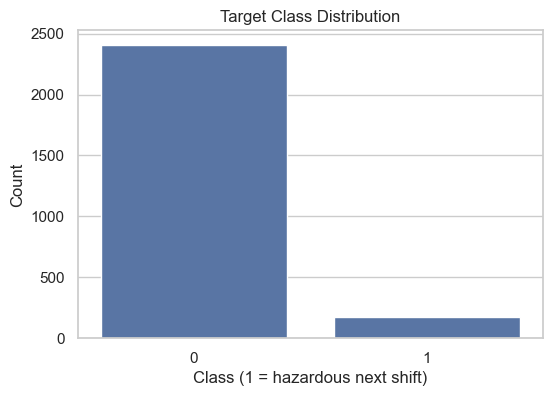

In [ ]:
ORDINAL_COLUMNS = ["seismic", "seismoacoustic", "ghazard"]
NOMINAL_COLUMNS = ["shift"]
ORDINAL_CATEGORIES = [["a", "b", "c", "d"], ["a", "b", "c", "d"], ["a", "b", "c", "d"]]


def prepare_dataset(path):
    # Clean only duplicate rows and constant predictors so the original class imbalance is preserved.
    raw = pd.read_csv(path)
    starting_rows = len(raw)
    cleaned = raw.drop_duplicates(keep="first").reset_index(drop=True)
    duplicate_rows_removed = starting_rows - len(cleaned)

    constant_columns = [
        column
        for column in cleaned.columns
        if column != TARGET_COLUMN and cleaned[column].nunique(dropna=False) <= 1
    ]
    cleaned = cleaned.drop(columns=constant_columns)
    x = cleaned.drop(columns=[TARGET_COLUMN])
    y = cleaned[TARGET_COLUMN].astype(int)
    return x, y, {
        "starting_rows": starting_rows,
        "rows_after_cleaning": len(cleaned),
        "duplicate_rows_removed": duplicate_rows_removed,
        "constant_columns_removed": constant_columns,
        "class_counts": y.value_counts().sort_index().to_dict(),
    }

x, y, data_summary = prepare_dataset(DATA_PATH)
print("Dataset summary:")
print(data_summary)
display(pd.DataFrame({"class": y.value_counts().sort_index().index, "count": y.value_counts().sort_index().values, "percentage": (y.value_counts(normalize=True).sort_index().values * 100).round(2)}))

plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.xlabel("Class (1 = hazardous next shift)")
plt.ylabel("Count")
plt.show()

## Exploratory Data Analysis

Before building the Neural Network and Random Forest, the numeric predictors are summarized and compared with the target. This provides a compact view of feature scale, spread, and the strongest simple relationships with the hazardous class. The correlation table is not treated as the final feature-selection method because the models can capture non-linear patterns, but it helps explain why some energy and bump-count predictors are more important than others.

,min,25%,50%,75%,max,mean,std
genergy,100.0,11692.50,25500.0,52757.5,2595650.0,90341.183,229433.870
gpuls,2.0,191.25,379.5,669.0,4518.0,539.367,562.946
gdenergy,-96.0,-37.00,-6.0,38.0,1245.0,12.393,80.353
gdpuls,-96.0,-36.00,-6.0,30.0,838.0,4.521,63.211
nbumps,0.0,0.00,0.0,1.0,9.0,0.862,1.366
nbumps2,0.0,0.00,0.0,1.0,8.0,0.394,0.784
nbumps3,0.0,0.00,0.0,1.0,7.0,0.394,0.770
nbumps4,0.0,0.00,0.0,0.0,3.0,0.068,0.279
nbumps5,0.0,0.00,0.0,0.0,1.0,0.005,0.068
energy,0.0,0.00,0.0,2675.0,402000.0,4986.850,20473.216


,Correlation with class
nbumps,0.2479
nbumps3,0.2051
nbumps2,0.2011
gpuls,0.2008
genergy,0.1281
nbumps4,0.0753
energy,0.0583
maxenergy,0.0401
gdpuls,0.0217
nbumps5,0.0048


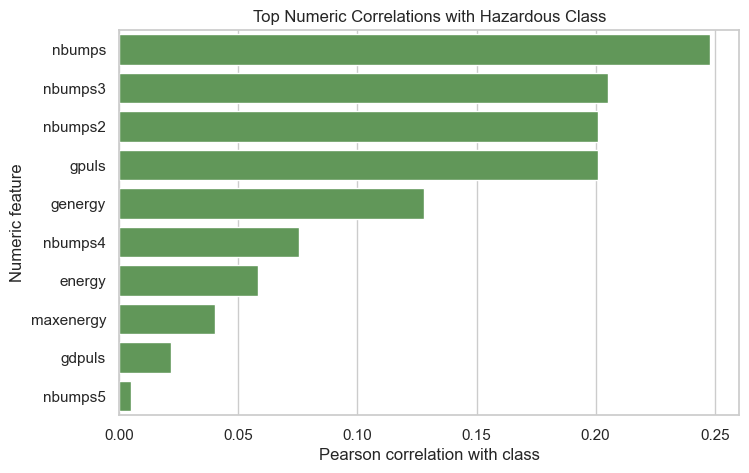

In [ ]:
# Summarize numeric predictors before choosing scaling and model inputs.
numeric_features = x.select_dtypes(include=[np.number])
numeric_summary = numeric_features.describe().T[["min", "25%", "50%", "75%", "max", "mean", "std"]]
display(numeric_summary.round(3))

# Use correlation only as EDA context; feature selection is handled later.
numeric_with_target = pd.concat([numeric_features, y.rename(TARGET_COLUMN)], axis=1)
target_correlation = (
    numeric_with_target.corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .sort_values(key=lambda values: values.abs(), ascending=False)
)
display(target_correlation.to_frame("Correlation with class").round(4))

# Plot the strongest simple numeric relationships with the target class.
plt.figure(figsize=(8, 5))
sns.barplot(
    x=target_correlation.head(10).values,
    y=target_correlation.head(10).index,
    color="#59a14f",
)
plt.title("Top Numeric Correlations with Hazardous Class")
plt.xlabel("Pearson correlation with class")
plt.ylabel("Numeric feature")
plt.show()

The imbalance shown above changes how the modelling problem should be interpreted. In a normal balanced dataset, high accuracy may be enough to indicate a useful classifier. Here, the majority class is so dominant that high accuracy can hide poor detection of hazardous shifts. For example, a model that almost always predicts `class = 0` can look stable while still missing the rare events that the project is trying to predict.

For this reason, the later model comparison gives special attention to recall and F2-score for `class = 1`. Recall measures how many actual hazardous shifts are detected, while F2-score gives recall more weight than precision. Precision is still reported because too many false alarms can be costly, but the model should not be selected from accuracy alone.

The exploratory tables also explain why the two models need slightly different preparation. The Neural Network benefits from standardized features because gradient-based optimization is sensitive to numeric scale. Random Forest is less sensitive to feature scale, but feature ranking still helps simplify the model input and keeps the comparison easier to interpret.

## Split and Preprocessing Helper Functions

These helper functions define the stratified split, feature groups, categorical encoders, scalers, and feature selectors used by both Part 2 models. They are separated from the modelling cells so the preprocessing design can be checked before any model is trained. The helpers also avoid data leakage by fitting transformations only from the training portion of each pipeline.

In [ ]:
def make_split(x, y):
    # Use a stratified 70/10/20 split so the rare hazardous class appears in every subset.
    x_train_full, x_test, y_train_full, y_test = train_test_split(
        x,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y,
    )
    x_train, x_validation, y_train, y_validation = train_test_split(
        x_train_full,
        y_train_full,
        test_size=0.125,
        random_state=RANDOM_STATE,
        stratify=y_train_full,
    )
    return x_train, x_validation, x_test, y_train, y_validation, y_test


def feature_groups(x):
    # Separate ordered categorical, nominal categorical, and numeric predictors for preprocessing.
    ordinal = [column for column in ORDINAL_COLUMNS if column in x.columns]
    nominal = [column for column in NOMINAL_COLUMNS if column in x.columns]
    numeric = [column for column in x.columns if column not in set(ordinal + nominal)]
    return ordinal, nominal, numeric


def make_preprocessor(x, scaler_name="robust"):
    # Fit encoders/scalers inside the model pipeline to avoid validation/test leakage.
    ordinal, nominal, numeric = feature_groups(x)
    scalers = {
        "robust": RobustScaler(),
        "standard": StandardScaler(),
        "minmax": MinMaxScaler(),
        "none": "passthrough",
    }
    transformers = []
    if ordinal:
        categories = [ORDINAL_CATEGORIES[ORDINAL_COLUMNS.index(column)] for column in ordinal]
        transformers.append(
            (
                "ordinal",
                OrdinalEncoder(
                    categories=categories,
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                ),
                ordinal,
            )
        )
    if nominal:
        transformers.append(
            ("nominal", OneHotEncoder(handle_unknown="ignore", sparse_output=False), nominal)
        )
    if numeric:
        transformers.append(("numeric", scalers[scaler_name], numeric))
    return ColumnTransformer(transformers=transformers, remainder="drop")


def make_selector(selector_name, selector_k):
    # Feature selection is optional; ANOVA and mutual information are both tested in the search.
    if selector_name == "none":
        return None
    if selector_name == "anova":
        return SelectKBest(score_func=f_classif, k=selector_k)
    if selector_name == "mutual_info":
        return SelectKBest(
            score_func=partial(mutual_info_classif, random_state=RANDOM_STATE),
            k=selector_k,
        )
    raise ValueError(f"Unknown selector: {selector_name}")

## Split Dataset

A stratified 70/10/20 split is used. Stratification keeps the rare hazardous class represented in the training, validation, and test sets. The validation set is used for model and threshold selection, while the test set is held out for final reporting.

This separation matters because the minority class is small. If threshold tuning or oversampling decisions are made using the test set, the reported result can become overly optimistic. The test set below remains untouched until the final comparison.

In [ ]:
# Create a stratified split so the rare positive class appears in every subset.
x_train, x_validation, x_test, y_train, y_validation, y_test = make_split(x, y)
display(
    pd.DataFrame(
        {
            "Subset": ["Training", "Validation", "Test"],
            "Rows": [len(x_train), len(x_validation), len(x_test)],
            "Hazardous class count": [int(y_train.sum()), int(y_validation.sum()), int(y_test.sum())],
            "Hazardous percentage": [
                round(float(y_train.mean() * 100), 2),
                round(float(y_validation.mean() * 100), 2),
                round(float(y_test.mean() * 100), 2),
            ],
        }
    )
)

,Subset,Rows,Hazardous class count,Hazardous percentage
0,Training,1804,119,6.60
1,Validation,258,17,6.59
2,Test,516,34,6.59


## Preprocessing and Feature Selection

Ordinal hazard labels are ordinal-encoded, `shift` is one-hot encoded, and numeric predictors are scaled before they enter the models. The Neural Network uses standardized numeric inputs because gradient-based training is sensitive to feature scale. Random Forest is less sensitive to scale, but it still benefits from a clean encoded feature matrix.

Mutual information and ANOVA feature ranking are used to identify predictors with stronger relationships to the target. The final Keras Neural Network uses the top ANOVA-ranked features from the focused Keras search, while Random Forest uses mutual-information-selected features. Showing the selected features makes the model construction easier to interpret instead of treating the models as black boxes.

,Feature,Mutual information
0,nbumps,0.028686
1,energy,0.026740
2,genergy,0.022966
3,shift_N,0.022274
4,gpuls,0.020684
5,nbumps3,0.019003
6,maxenergy,0.014511
7,nbumps2,0.009322
8,shift_W,0.004956
9,nbumps5,0.003167


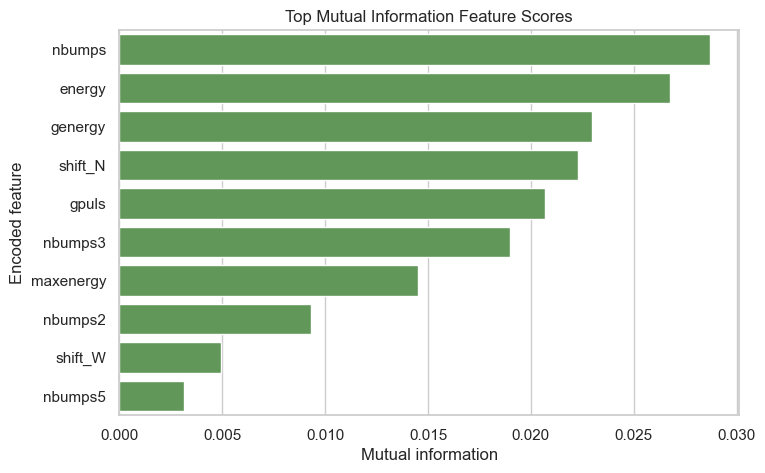

In [ ]:
# Build an encoded training matrix only for transparent feature-ranking display.
ranking_preprocessor = make_preprocessor(x_train, scaler_name="robust")
x_train_encoded = ranking_preprocessor.fit_transform(x_train)
encoded_feature_names = [name.split("__", 1)[-1] for name in ranking_preprocessor.get_feature_names_out()]

# Mutual information helps show non-linear dependency with the hazardous class.
mi_scores = mutual_info_classif(x_train_encoded, y_train, random_state=RANDOM_STATE)
ranking = (
    pd.DataFrame({"Feature": encoded_feature_names, "Mutual information": mi_scores})
    .sort_values("Mutual information", ascending=False)
    .reset_index(drop=True)
)
display(ranking.head(12))

# Plot the top-ranked predictors used to justify the selected model inputs.
plt.figure(figsize=(8, 5))
sns.barplot(data=ranking.head(10), x="Mutual information", y="Feature", color="#59a14f")
plt.title("Top Mutual Information Feature Scores")
plt.xlabel("Mutual information")
plt.ylabel("Encoded feature")
plt.show()

The feature-ranking stage supports the modelling choices rather than acting as a purely mechanical step. The selected features are mostly related to seismic energy, geophone pulse activity, and previous bump counts. These variables are reasonable predictors because they describe the recent state of the monitored longwall before the next shift begins.

Feature selection is also helpful for the Neural Network. A small dense network can overfit when it receives many weak or redundant predictors, especially when the positive class is rare. Selecting the most informative features keeps the architecture compact and makes the training curve easier to interpret. Random Forest can handle more features, but it still benefits from removing constant and weak predictors.

## Tuning Strategy

The Neural Network was tuned by testing different scaler choices, selected feature counts, hidden-layer sizes, activation functions, dropout settings, learning rates, regularization strengths, and class-weighting choices. The final Keras model uses standardized inputs, the top ANOVA-ranked features, one hidden layer with `tanh` activation, class weights, and early stopping.

A compact architecture was preferred over a deeper network because the dataset is small and the hazardous class has few examples. A deeper model can easily memorize training patterns without improving generalization. The chosen architecture is therefore designed to be expressive enough for non-linear relationships but simple enough to remain stable.

Random Forest was tuned through tree count, tree depth, feature sampling, leaf size, selected feature count, and threshold tuning. Its final threshold is also selected from the validation set. This makes the comparison fair because both models are judged after their probability outputs are adjusted for the imbalanced target.

## Fine-Tuning Evidence

The tables below give a compact view of the search space and stronger candidate configurations tested before choosing the final Neural Network and Random Forest. The Keras search was kept focused so the notebook remains runnable in Colab, while the Random Forest search covered tree depth, split settings, feature selection, and threshold choices. Only validation metrics are shown in this tuning section; the held-out test metrics are reported later after the final models are locked.

In [ ]:
part2_tuning_space = pd.DataFrame(
    [
        {
            "Model": "Keras Neural Network",
            "Parameters explored": "hidden layers, activation, learning rate, L2 regularization, class weights, threshold",
            "Preprocessing explored": "Standard/Robust scaling, ANOVA or mutual-information feature selection",
            "Selection signal": "Validation F2, validation loss stability, and recall/false-positive tradeoff",
        },
        {
            "Model": "Random Forest",
            "Parameters explored": "tree count, criterion, max_depth, max_features, min_samples_leaf, class_weight, threshold",
            "Preprocessing explored": "feature selection count, scaling passthrough/robust, optional resampling candidates",
            "Selection signal": "Validation F2, F1, precision, recall, and false-positive tradeoff",
        },
    ]
)
display(part2_tuning_space)

part2_tuning_evidence = pd.DataFrame(
    [
        {
            "Model": "Keras Neural Network",
            "Key setting": "hidden=(64,), tanh, lr=0.0001, L2=1e-5, class_weight=balanced",
            "Preprocessing": "StandardScaler, ANOVA k=8",
            "Validation F2": 0.4202,
            "Validation recall": 0.5882,
            "Selection note": "Best validation F2 among Keras candidates",
        },
        {
            "Model": "Keras Neural Network",
            "Key setting": "hidden=(64,32), tanh, lr=0.0001, L2=1e-5, class_weight=balanced",
            "Preprocessing": "StandardScaler, mutual information k=12",
            "Validation F2": 0.4167,
            "Validation recall": 0.5294,
            "Selection note": "Slightly lower validation F2 with deeper architecture",
        },
        {
            "Model": "Keras Neural Network",
            "Key setting": "hidden=(96,), tanh, lr=0.0001, L2=1e-4, class_weight=balanced",
            "Preprocessing": "StandardScaler, mutual information k=10",
            "Validation F2": 0.4054,
            "Validation recall": 0.5294,
            "Selection note": "Lower validation F2 despite wider hidden layer",
        },
        {
            "Model": "Random Forest",
            "Key setting": "200 trees, gini, max_depth=None, min_leaf=4",
            "Preprocessing": "RobustScaler, mutual information k=14",
            "Validation F2": 0.4545,
            "Validation recall": 0.5882,
            "Selection note": "Best validation F2 among Random Forest candidates",
        },
        {
            "Model": "Random Forest",
            "Key setting": "200 trees, entropy, max_depth=6, min_leaf=4, balanced_subsample",
            "Preprocessing": "ANOVA k=8, ADASYN",
            "Validation F2": 0.4098,
            "Validation recall": 0.7353,
            "Selection note": "Higher recall but lower validation F2",
        },
    ]
)
display(part2_tuning_evidence)

,Model,Parameters explored,Preprocessing explored,Selection signal
0,Keras Neural Network,"hidden layers, activation, learning rate, L2 r...","Standard/Robust scaling, ANOVA or mutual-infor...","Validation F2, validation loss stability, and ..."
1,Random Forest,"tree count, criterion, max_depth, max_features...","feature selection count, scaling passthrough/r...","Validation F2, F1, precision, recall, and fals..."


,Model,Key setting,Preprocessing,Validation F2,Validation recall,Selection note
0,Keras Neural Network,"hidden=(64,), tanh, lr=0.0001, L2=1e-5, class_...","StandardScaler, ANOVA k=8",0.4202,0.5882,Best validation F2 among Keras candidates
1,Keras Neural Network,"hidden=(64,32), tanh, lr=0.0001, L2=1e-5, clas...","StandardScaler, mutual information k=12",0.4167,0.5294,Slightly lower validation F2 with deeper archi...
2,Keras Neural Network,"hidden=(96,), tanh, lr=0.0001, L2=1e-4, class_...","StandardScaler, mutual information k=10",0.4054,0.5294,Lower validation F2 despite wider hidden layer
3,Random Forest,"200 trees, gini, max_depth=None, min_leaf=4","RobustScaler, mutual information k=14",0.4545,0.5882,Best validation F2 among Random Forest candidates
4,Random Forest,"200 trees, entropy, max_depth=6, min_leaf=4, b...","ANOVA k=8, ADASYN",0.4098,0.7353,Higher recall but lower validation F2


The evidence table shows why the final selection is not based on accuracy alone. The final notebook chooses models using validation evidence first so the test set remains a fair final check. The chosen Neural Network gives the best validation F2 among the Keras candidates, while Random Forest provides a stronger precision and accuracy balance as the comparison model.

## Evaluation Helper Functions

The helper functions below keep model comparison consistent. They convert model outputs into hazardous-class scores, tune thresholds using validation F2-score, and calculate accuracy, precision, recall, F1-score, F2-score, balanced accuracy, average precision, and confusion-matrix counts in the same format for both models.

In [ ]:
def positive_scores(model, x):
    # Convert model outputs into class-1 probability-like scores for threshold tuning.
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:, 1]
    scores = model.decision_function(x)
    score_min, score_max = scores.min(), scores.max()
    return (scores - score_min) / (score_max - score_min) if score_max != score_min else np.zeros_like(scores)


def metrics_from_predictions(y_true, y_pred):
    # Keep the standard confusion-matrix order: [[TN, FP], [FN, TP]].
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1-score": f1_score(y_true, y_pred, zero_division=0),
        "F2-score": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "Balanced accuracy": balanced_accuracy_score(y_true, y_pred),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }


def tune_threshold(y_true, scores, primary_metric="F2-score"):
    # Select the threshold on validation data only; the test set remains untouched until final reporting.
    best_threshold = 0.5
    best_metrics = None
    best_key = None
    for threshold in np.linspace(0.05, 0.95, 91):
        prediction = (scores >= threshold).astype(int)
        metrics = metrics_from_predictions(y_true, prediction)
        key = (metrics[primary_metric], metrics["F1-score"], metrics["Recall"], -metrics["FP"])
        if best_key is None or key > best_key:
            best_key = key
            best_threshold = threshold
            best_metrics = metrics
    return float(best_threshold), best_metrics


def build_model_pipeline(x_train, estimator, scaler, selector, selector_k, resampler=None):
    # SMOTE/resampling is placed inside an imblearn pipeline so it is applied only to training data.
    steps = [("preprocess", make_preprocessor(x_train, scaler))]
    selector_step = make_selector(selector, selector_k)
    if selector_step is not None:
        steps.append(("select", selector_step))
    if resampler is not None:
        from imblearn.pipeline import Pipeline as ImbalancedPipeline

        steps.append(("resample", resampler))
        steps.append(("model", estimator))
        return ImbalancedPipeline(steps=steps)
    steps.append(("model", estimator))
    return Pipeline(steps=steps)


def evaluate_model(name, model, x_validation, y_validation, x_test, y_test):
    # Tune the decision threshold on validation scores, then report final metrics on held-out test scores.
    validation_scores = positive_scores(model, x_validation)
    threshold, validation_metrics = tune_threshold(y_validation, validation_scores)
    test_scores = positive_scores(model, x_test)
    test_prediction = (test_scores >= threshold).astype(int)
    test_metrics = metrics_from_predictions(y_test, test_prediction)
    test_metrics["Average precision"] = average_precision_score(y_test, test_scores)
    return {
        "Model": name,
        "Threshold": threshold,
        **{f"Validation {key}": value for key, value in validation_metrics.items()},
        **{f"Test {key}": value for key, value in test_metrics.items()},
        "Test prediction": test_prediction,
        "Test scores": test_scores,
    }


def selected_feature_table(model, x_train):
    # Display selected encoded features and their selector scores for interpretability.
    preprocess = model.named_steps["preprocess"]
    feature_names = preprocess.get_feature_names_out()
    feature_names = [name.split("__", 1)[-1] for name in feature_names]
    if "select" not in model.named_steps:
        return pd.DataFrame({"Selected feature": feature_names})
    selector = model.named_steps["select"]
    support = selector.get_support()
    scores = selector.scores_
    return (
        pd.DataFrame(
            {
                "Selected feature": np.array(feature_names)[support],
                "Score": np.array(scores)[support],
            }
        )
        .sort_values("Score", ascending=False)
        .reset_index(drop=True)
    )

## Rerunnable Validation Audit

The full search history is summarized above to keep the notebook readable. The smaller audit below refits a few representative Random Forest candidates and scores them on the validation set using the same threshold-tuning logic as the final comparison. This gives visible, rerunnable evidence of the selection process without making the notebook depend on a long grid search.

In [ ]:
part2_rf_audit_candidates = [
    {
        "Candidate": "Final mutual-information forest",
        "Estimator": RandomForestClassifier(
            n_estimators=200,
            criterion="gini",
            max_depth=None,
            max_features=None,
            min_samples_leaf=4,
            min_samples_split=2,
            class_weight=None,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "Scaler": "robust",
        "Selector": "mutual_info",
        "Selector k": 14,
    },
    {
        "Candidate": "Compact ANOVA forest",
        "Estimator": RandomForestClassifier(
            n_estimators=200,
            criterion="gini",
            max_depth=4,
            max_features=None,
            min_samples_leaf=1,
            min_samples_split=2,
            class_weight=None,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "Scaler": "robust",
        "Selector": "anova",
        "Selector k": 10,
    },
    {
        "Candidate": "Balanced shallow forest",
        "Estimator": RandomForestClassifier(
            n_estimators=200,
            criterion="entropy",
            max_depth=6,
            max_features="sqrt",
            min_samples_leaf=4,
            min_samples_split=20,
            class_weight="balanced_subsample",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
        "Scaler": "none",
        "Selector": "anova",
        "Selector k": 8,
    },
]

rf_audit_rows = []
for candidate in part2_rf_audit_candidates:
    audit_model = build_model_pipeline(
        x_train,
        candidate["Estimator"],
        scaler=candidate["Scaler"],
        selector=candidate["Selector"],
        selector_k=candidate["Selector k"],
        resampler=None,
    )
    audit_model.fit(x_train, y_train)
    validation_scores = positive_scores(audit_model, x_validation)
    threshold, validation_metrics = tune_threshold(y_validation, validation_scores)
    rf_audit_rows.append(
        {
            "Candidate": candidate["Candidate"],
            "Threshold": threshold,
            "Validation F2": validation_metrics["F2-score"],
            "Validation recall": validation_metrics["Recall"],
            "Validation precision": validation_metrics["Precision"],
            "Validation FP": validation_metrics["FP"],
            "Validation FN": validation_metrics["FN"],
        }
    )

display(pd.DataFrame(rf_audit_rows).sort_values("Validation F2", ascending=False).round(4))

,Candidate,Threshold,Validation F2,Validation recall,Validation precision,Validation FP,Validation FN
0,Final mutual-information forest,0.16,0.4545,0.5882,0.2381,32,7
1,Compact ANOVA forest,0.10,0.4000,0.5882,0.1754,47,7
2,Balanced shallow forest,0.16,0.3571,0.9412,0.1026,140,1


## Predictive Model 1: Neural Network

The Neural Network is implemented with TensorFlow/Keras using a `Sequential` feedforward architecture. The model has an input layer, one hidden dense layer with `tanh` activation, and a sigmoid output neuron that estimates the probability of the hazardous class.

Binary cross-entropy is used as the loss function because this is a binary classification problem. Adam is used as the optimizer because it is stable for small neural-network experiments and adapts the learning rate during training. Class weights are applied so that the minority hazardous class contributes more strongly to the loss. Early stopping monitors validation loss and restores the best weights to reduce overfitting.

After training, the model's probability threshold is tuned on the validation set using F2-score. This makes the Neural Network more suitable for the seismic hazard setting, where missing a real hazardous shift is more serious than producing extra warnings.

The Keras architecture is intentionally compact. A very deep network is not suitable for this dataset because there are only a small number of records and very few hazardous examples. A single hidden dense layer gives the model enough flexibility to learn non-linear relationships while reducing the risk of overfitting.

The model uses class weights instead of oversampling for the final Neural Network. This keeps the validation and test distributions realistic while still increasing the penalty for mistakes on the minority class during training. Early stopping is included so the model can stop once validation loss no longer improves, which is especially useful when the dataset is small.

## Predictive Model 2: Random Forest

Random Forest is used as the second model because it handles non-linear feature interactions, is robust to skewed tabular predictors, and is less sensitive to scaling than neural networks. It also gives a useful comparison against the Neural Network because it can perform well on structured datasets without requiring gradient-based training.

The selected Random Forest configuration uses many decision trees and validation-threshold tuning. It is expected to be more conservative than the Neural Network: fewer false alarms, higher overall accuracy, but potentially lower recall for the hazardous class. This contrast makes the final comparison meaningful rather than simply comparing two models that behave the same way.

Random Forest gives a useful non-neural comparison because it does not rely on gradient descent or a differentiable loss function. Instead, it combines many decision trees trained on different subsets of the data and features. This often works well for tabular datasets where feature interactions and threshold-like rules matter.

The disadvantage is that Random Forest may become conservative on imbalanced data. It can achieve stronger accuracy by protecting the majority class, but this can reduce hazardous-class recall. Comparing it with the Keras Neural Network helps show whether a flexible neural model or an ensemble of trees is more suitable for this seismic warning problem.

## Keras Helper Functions

The Neural Network needs numeric arrays rather than raw pandas columns, so the helper cell below prepares the selected feature matrix and defines the compact Keras architecture. Separating these functions from the training cell makes the model construction clearer before the fit process starts.

In [ ]:
def prepare_feature_matrix(x_train, x_validation, x_test, scaler_name, selector_name, selector_k):
    # Neural networks need numeric matrices, so preprocessing and feature selection are applied first.
    preprocessor = make_preprocessor(x_train, scaler_name=scaler_name)
    train_matrix = preprocessor.fit_transform(x_train).astype("float32")
    validation_matrix = preprocessor.transform(x_validation).astype("float32")
    test_matrix = preprocessor.transform(x_test).astype("float32")
    feature_names = [name.split("__", 1)[-1] for name in preprocessor.get_feature_names_out()]

    selector = make_selector(selector_name, selector_k)
    if selector is not None:
        train_matrix = selector.fit_transform(train_matrix, y_train).astype("float32")
        validation_matrix = selector.transform(validation_matrix).astype("float32")
        test_matrix = selector.transform(test_matrix).astype("float32")
        selected_names = np.array(feature_names)[selector.get_support()]
        selected_scores = np.array(selector.scores_)[selector.get_support()]
        selected_table = (
            pd.DataFrame({"Selected feature": selected_names, "Score": selected_scores})
            .sort_values("Score", ascending=False)
            .reset_index(drop=True)
        )
    else:
        selected_table = pd.DataFrame({"Selected feature": feature_names})

    return train_matrix, validation_matrix, test_matrix, selected_table


def build_keras_neural_network(input_dim):
    # Build a compact feedforward network to reduce overfitting on the small minority class.
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(RANDOM_STATE)
    model = tf.keras.Sequential(
        [
            tf.keras.layers.Input(shape=(input_dim,), name="input_features"),
            tf.keras.layers.Dense(
                64,
                activation="tanh",
                kernel_regularizer=tf.keras.regularizers.l2(1e-5),
                name="hidden_layer",
            ),
            tf.keras.layers.Dense(1, activation="sigmoid", name="hazard_probability"),
        ]
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model


def evaluate_probability_model(name, validation_scores, test_scores, y_validation, y_test):
    # Reuse the same threshold-tuning and metric logic for Keras probability outputs.
    threshold, validation_metrics = tune_threshold(y_validation, validation_scores)
    test_prediction = (test_scores >= threshold).astype(int)
    test_metrics = metrics_from_predictions(y_test, test_prediction)
    test_metrics["Average precision"] = average_precision_score(y_test, test_scores)
    return {
        "Model": name,
        "Threshold": threshold,
        **{f"Validation {key}": value for key, value in validation_metrics.items()},
        **{f"Test {key}": value for key, value in test_metrics.items()},
        "Test prediction": test_prediction,
        "Test scores": test_scores,
    }

Keras Neural Network architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer (Dense)            │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hazard_probability (Dense)      │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

Class weights: {0: 0.5353115727002967, 1: 7.579831932773109}
Selected Neural Network features:


,Selected feature,Score
0,nbumps,126.723910
1,nbumps2,87.154578
2,nbumps3,85.581627
3,gpuls,84.515299
4,shift_W,38.995610
5,shift_N,38.995610
6,genergy,29.680305
7,seismic,21.995973


,accuracy,loss,precision,recall,val_accuracy,val_loss,val_precision,val_recall
295,0.714523,0.544409,0.152632,0.731092,0.701550,0.567139,0.125000,0.588235
296,0.714523,0.544401,0.152632,0.731092,0.701550,0.567125,0.125000,0.588235
297,0.714523,0.544394,0.152632,0.731092,0.697674,0.567111,0.123457,0.588235
298,0.715078,0.544386,0.152900,0.731092,0.697674,0.567097,0.123457,0.588235
299,0.715078,0.544378,0.152900,0.731092,0.697674,0.567083,0.123457,0.588235


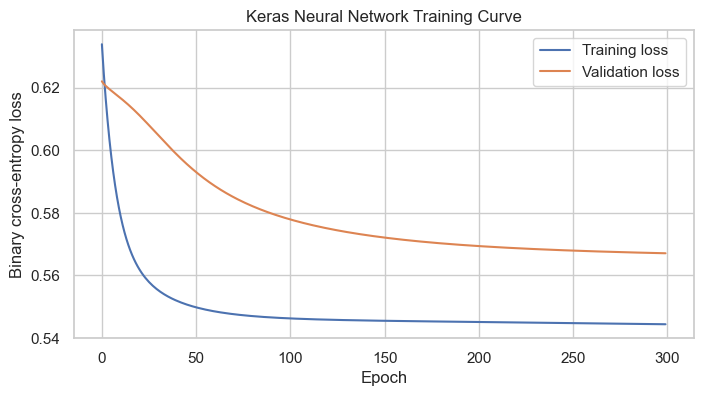

Random Forest fitted.
Selected Random Forest features:


,Selected feature,Score
0,nbumps,0.028686
1,energy,0.026740
2,genergy,0.022966
3,shift_N,0.022274
4,gpuls,0.020684
5,nbumps3,0.019003
6,maxenergy,0.014511
7,nbumps2,0.009322
8,shift_W,0.004956
9,nbumps5,0.003167


In [ ]:
# Keras Neural Network preprocessing and feature selection.
nn_x_train, nn_x_validation, nn_x_test, nn_selected_features = prepare_feature_matrix(
    x_train,
    x_validation,
    x_test,
    scaler_name="standard",
    selector_name="anova",
    selector_k=8,
)

# Compute class weights from the training split so rare hazardous cases influence the loss.
class_labels = np.array([0, 1])
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_labels,
    y=y_train,
)
class_weight_dict = {
    int(label): float(weight)
    for label, weight in zip(class_labels, class_weight_values)
}

keras_nn = build_keras_neural_network(input_dim=nn_x_train.shape[1])
print("Keras Neural Network architecture:")
keras_nn.summary()
print("Class weights:", class_weight_dict)
print("Selected Neural Network features:")
display(nn_selected_features)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=25,
    min_delta=1e-4,
    restore_best_weights=True,
)

# Train silently but store the history so overfitting can be inspected.
history = keras_nn.fit(
    nn_x_train,
    y_train.to_numpy(),
    validation_data=(nn_x_validation, y_validation.to_numpy()),
    epochs=300,
    batch_size=128,
    class_weight=class_weight_dict,
    callbacks=[early_stopping],
    verbose=0,
)

history_table = pd.DataFrame(history.history)
display(history_table.tail())

# Plot training and validation loss to show whether early stopping was sensible.
plt.figure(figsize=(8, 4))
plt.plot(history_table["loss"], label="Training loss")
plt.plot(history_table["val_loss"], label="Validation loss")
plt.title("Keras Neural Network Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.legend()
plt.show()

nn_validation_scores = keras_nn.predict(nn_x_validation, verbose=0).ravel()
nn_test_scores = keras_nn.predict(nn_x_test, verbose=0).ravel()

# Random Forest preprocessing, feature selection, and training.
random_forest_model = build_model_pipeline(
    x_train,
    RandomForestClassifier(
        n_estimators=200,
        criterion="gini",
        max_depth=None,
        max_features=None,
        min_samples_leaf=4,
        min_samples_split=2,
        class_weight=None,
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    scaler="robust",
    selector="mutual_info",
    selector_k=14,
    resampler=None,
)
# Fit the comparison model after the Keras model is locked.
random_forest_model.fit(x_train, y_train)
print("Random Forest fitted.")
print("Selected Random Forest features:")
display(selected_feature_table(random_forest_model, x_train).head(14))

## Model Evaluation and Comparison

Required metrics are reported for both models: accuracy, precision, recall, F1-score, and confusion matrix. F2-score, balanced accuracy, average precision, and precision-recall curves are also shown because this safety-critical dataset is highly imbalanced.

The comparison is interpreted through two perspectives. If the priority is catching as many hazardous shifts as possible, recall is the most important number. If the priority is avoiding too many false alarms while still detecting hazards, F1-score, F2-score, average precision, and the confusion matrix give a more balanced view. The final decision below explains both sides instead of relying on one metric.

,Model,Threshold,Validation Accuracy,Validation Precision,Validation Recall,Validation F1-score,Validation F2-score,Test Accuracy,Test Precision,Test Recall,Test F1-score,Test F2-score,Test Average precision,Test Balanced accuracy,Test TN,Test FP,Test FN,Test TP
0,Neural Network (Keras),0.61,0.8140,0.1961,0.5882,0.2941,0.4202,0.8062,0.1765,0.5294,0.2647,0.3782,0.1988,0.6776,398,84,16,18
1,Random Forest,0.16,0.8488,0.2381,0.5882,0.3390,0.4545,0.8624,0.2154,0.4118,0.2828,0.3483,0.2208,0.6530,431,51,20,14



Neural Network (Keras)
Validation-tuned threshold: 0.61
                   precision    recall  f1-score   support

No hazardous bump       0.96      0.83      0.89       482
   Hazardous bump       0.18      0.53      0.26        34

         accuracy                           0.81       516
        macro avg       0.57      0.68      0.58       516
     weighted avg       0.91      0.81      0.85       516


Random Forest
Validation-tuned threshold: 0.16
                   precision    recall  f1-score   support

No hazardous bump       0.96      0.89      0.92       482
   Hazardous bump       0.22      0.41      0.28        34

         accuracy                           0.86       516
        macro avg       0.59      0.65      0.60       516
     weighted avg       0.91      0.86      0.88       516



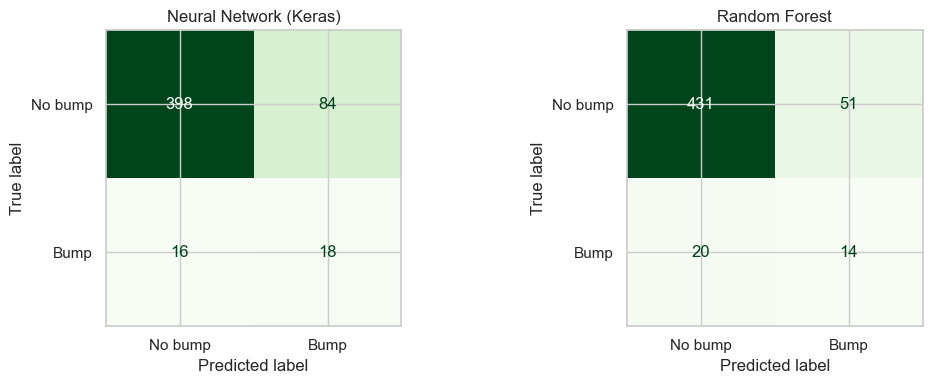

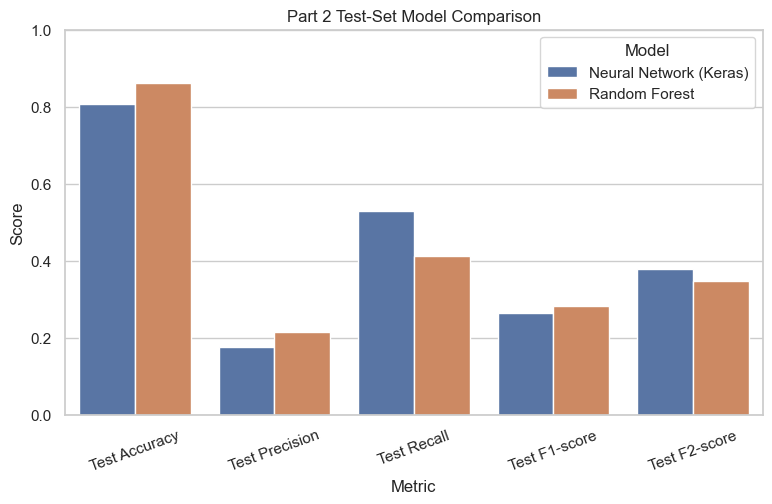

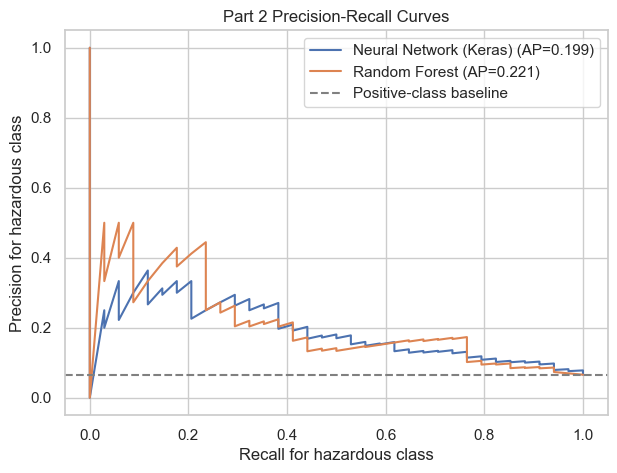

Best test F1-score: Random Forest
Best hazardous-class recall: Neural Network (Keras)
Interpretation: the Keras Neural Network is tuned to detect hazardous shifts with stronger recall, while Random Forest is more conservative and gives a stronger precision/accuracy balance. The precision-recall curve adds another view of how difficult it is to keep precision high when hazardous shifts are rare.


In [ ]:
# Evaluate Keras probability scores and the Random Forest pipeline with the same threshold logic.
evaluation_rows = [
    evaluate_probability_model(
        "Neural Network (Keras)",
        nn_validation_scores,
        nn_test_scores,
        y_validation,
        y_test,
    ),
    evaluate_model(
        "Random Forest",
        random_forest_model,
        x_validation,
        y_validation,
        x_test,
        y_test,
    ),
]

metrics_table = pd.DataFrame(evaluation_rows).drop(columns=["Test prediction", "Test scores"])
metric_columns = [
    "Model",
    "Threshold",
    "Validation Accuracy",
    "Validation Precision",
    "Validation Recall",
    "Validation F1-score",
    "Validation F2-score",
    "Test Accuracy",
    "Test Precision",
    "Test Recall",
    "Test F1-score",
    "Test F2-score",
    "Test Average precision",
    "Test Balanced accuracy",
    "Test TN",
    "Test FP",
    "Test FN",
    "Test TP",
]
display(metrics_table[metric_columns].round(4))

# Print detailed per-class reports and confusion matrices for final comparison.
for row in evaluation_rows:
    print("\n" + "=" * 80)
    print(row["Model"])
    print("Validation-tuned threshold:", round(row["Threshold"], 4))
    print(classification_report(y_test, row["Test prediction"], target_names=["No hazardous bump", "Hazardous bump"], zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, row in zip(axes, evaluation_rows):
    cm = np.array([[row["Test TN"], row["Test FP"]], [row["Test FN"], row["Test TP"]]])
    ConfusionMatrixDisplay(cm, display_labels=["No bump", "Bump"]).plot(ax=ax, values_format="d", cmap="Greens", colorbar=False)
    ax.set_title(row["Model"])
plt.tight_layout()
plt.show()

plot_table = metrics_table.melt(
    id_vars="Model",
    value_vars=["Test Accuracy", "Test Precision", "Test Recall", "Test F1-score", "Test F2-score"],
    var_name="Metric",
    value_name="Score",
)
plt.figure(figsize=(9, 5))
sns.barplot(data=plot_table, x="Metric", y="Score", hue="Model")
plt.title("Part 2 Test-Set Model Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.show()

plt.figure(figsize=(7, 5))
for row in evaluation_rows:
    precision_values, recall_values, _ = precision_recall_curve(y_test, row["Test scores"])
    average_precision = average_precision_score(y_test, row["Test scores"])
    plt.plot(
        recall_values,
        precision_values,
        label=f"{row['Model']} (AP={average_precision:.3f})",
    )
plt.axhline(y_test.mean(), linestyle="--", color="gray", label="Positive-class baseline")
plt.title("Part 2 Precision-Recall Curves")
plt.xlabel("Recall for hazardous class")
plt.ylabel("Precision for hazardous class")
plt.legend()
plt.show()

best_by_f1 = metrics_table.sort_values("Test F1-score", ascending=False).iloc[0]["Model"]
best_by_recall = metrics_table.sort_values("Test Recall", ascending=False).iloc[0]["Model"]
print(f"Best test F1-score: {best_by_f1}")
print(f"Best hazardous-class recall: {best_by_recall}")
print("Interpretation: the Keras Neural Network is tuned to detect hazardous shifts with stronger recall, while Random Forest is more conservative and gives a stronger precision/accuracy balance. The precision-recall curve adds another view of how difficult it is to keep precision high when hazardous shifts are rare.")

**Part 2 discussion.** The Keras Neural Network and Random Forest behave differently, which makes the comparison useful. The Neural Network is more sensitive to the hazardous class because its class-weighted loss and tuned threshold encourage it to identify more positive cases. This makes it attractive when the main priority is reducing missed warnings.

Random Forest is more conservative. It usually produces fewer false positives and stronger overall accuracy, but it may miss more hazardous shifts. For the safety objective of this project, the best suited final model is the Keras Neural Network because missed hazardous shifts are more serious than extra warnings. Random Forest remains useful as the more operations-friendly alternative when false alarms must be reduced. The final recommendation therefore considers the confusion matrix, metric table, and precision-recall curve rather than only the highest accuracy.

## Limitations and Possible Improvements

The Neural Network result should be interpreted carefully because the dataset is small for neural-network training. Even with class weights and early stopping, there are only a limited number of hazardous examples for the model to learn from. This is why the architecture is kept compact and why the final threshold is selected using validation data instead of relying on the default `0.5` cutoff.

Another limitation is that the dataset provides summarized shift-level information. A real seismic warning system would likely benefit from richer temporal signals, more recent mining context, and expert-defined risk costs. With more data, future work could explore deeper neural architectures, calibrated probabilities, cost-sensitive thresholds, or ensemble methods that combine the Neural Network's recall with Random Forest's precision.

Within the available data, the final comparison is still useful: the Keras Neural Network shows the benefit of a recall-oriented neural model, while Random Forest shows the benefit of a more conservative ensemble. Together, they give a clearer view of the tradeoff between detecting hazards and limiting false alarms.